In [1]:
# Acesso à raiz do projeto

import sys
import os

# Caminho até a raiz do projeto
sys.path.append(os.path.abspath("../../"))


In [2]:
# Importação das bibliotecas necessárias

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from modulos.gerais import exibir_resultado, exibir_relatorio_de_classificacao, preparar_digits
from modulos.arvore_de_decisao import executar_arvore_de_decisao, exibir_regras_da_arvore_de_decisao, gerar_grafico_da_arvore_de_decisao


In [3]:
# Importação e exploração dos dados
digits = load_digits()
X, y, feature_names, target_names = preparar_digits(digits)

target_names = [str(nome) for nome in digits.target_names]

# Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y
)


In [4]:
(clf, y_pred_arvore_de_decisao, acuracia_arvore_decisao, precisao_arvore_decisao,
revocacao_arvore_decisao, f1_arvore_decisao) = executar_arvore_de_decisao(X_train, y_train, X_test, y_test)


C:\Users\Henrique\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [5]:
# Exibição dos resultados das métricas usando Árvore de Decisão com Digits
exibir_resultado(
    acuracia_arvore_decisao, precisao_arvore_decisao,
    revocacao_arvore_decisao, f1_arvore_decisao,
    "ÁRVORE DE DECISÃO"
    )


MÉTRICAS DE AVALIAÇÃO - ÁRVORE DE DECISÃO
Acurácia:  0.4593
Precisão:  0.3849
Revocação: 0.4560
F1-Score:  0.3769




In [6]:
# Exibição das Regras Geradas
exibir_regras_da_arvore_de_decisao(clf, feature_names)



REGRAS DA ÁRVORE DE DECISÃO (FORMATO TEXTO):
|--- pixel_4_4 <= 0.50
|   |--- pixel_5_2 <= 5.00
|   |   |--- pixel_1_5 <= 7.50
|   |   |   |--- class: 5
|   |   |--- pixel_1_5 >  7.50
|   |   |   |--- class: 9
|   |--- pixel_5_2 >  5.00
|   |   |--- pixel_1_5 <= 1.00
|   |   |   |--- class: 4
|   |   |--- pixel_1_5 >  1.00
|   |   |   |--- class: 0
|--- pixel_4_4 >  0.50
|   |--- pixel_2_5 <= 0.50
|   |   |--- pixel_5_2 <= 7.50
|   |   |   |--- class: 5
|   |   |--- pixel_5_2 >  7.50
|   |   |   |--- class: 6
|   |--- pixel_2_5 >  0.50
|   |   |--- pixel_4_1 <= 4.50
|   |   |   |--- class: 3
|   |   |--- pixel_4_1 >  4.50
|   |   |   |--- class: 4



In [7]:
# Exibição do relatório de classificação da Árvore de Decisão com Digits
exibir_relatorio_de_classificacao(y_test, y_pred_arvore_de_decisao, target_names)


==================== RELATÓRIO DE CLASSIFICAÇÃO ====================
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        54
           1       0.00      0.00      0.00        55
           2       0.00      0.00      0.00        53
           3       0.19      0.89      0.32        55
           4       0.61      0.69      0.64        54
           5       0.59      0.85      0.70        55
           6       0.69      0.91      0.78        54
           7       0.00      0.00      0.00        54
           8       0.00      0.00      0.00        52
           9       0.88      0.26      0.40        54

    accuracy                           0.46       540
   macro avg       0.38      0.46      0.38       540
weighted avg       0.39      0.46      0.38       540



C:\Users\Henrique\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Henrique\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Henrique\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

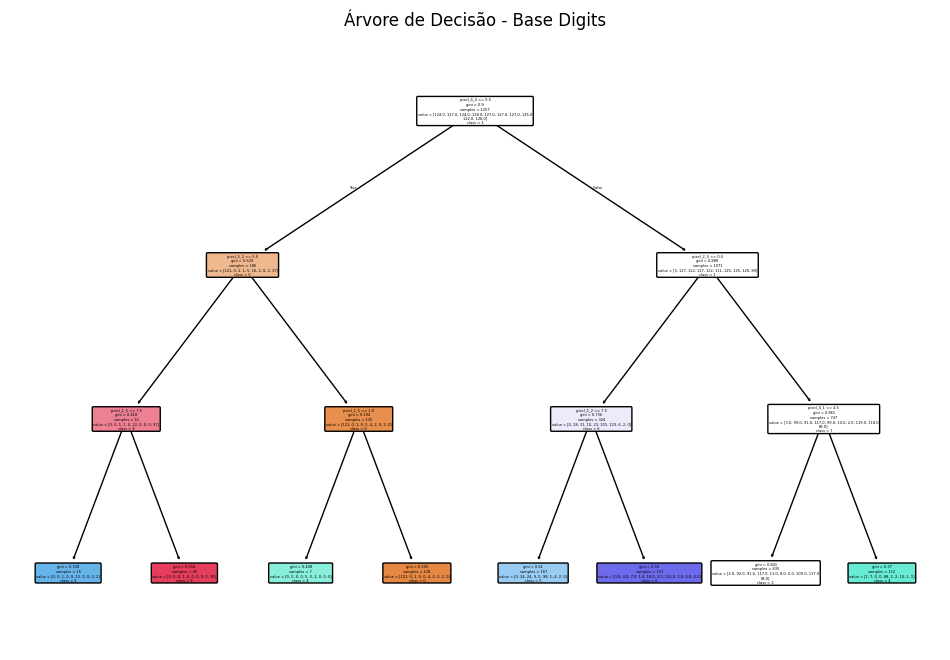

In [8]:
# Representação Gráfica da Árvore
gerar_grafico_da_arvore_de_decisao(clf, feature_names, target_names, 'Digits')
